# CCUS patent VAE study

This notebook consolidates the modelling, baselines and evaluation.

The notebook fixes all available random seeds, uses deterministic PyTorch settings where supported, applies stable tie-breaking in ranking calculations, and clears old figure/table outputs at the start so stale UMAP files are not accidentally uploaded.

Expected input file:

`/content/drive/MyDrive/Colab Notebooks/Patents_Adventure/patents_cleaned_subset_10k.csv`

Main output folders:

`figuresForPaper2/` for figures, `tablesForPaper2/` for LaTeX tables and result macros, and `preprocessed/` for split matrices and metadata.


## 1. Install dependencies and import libraries

Run this cell at the start of a fresh Colab session.


In [ ]:

# Environment setup. Restarting the runtime after this cell is usually not necessary,
# but if Colab reports dependency conflicts, restart once and continue from the next cell.
!pip -q install --upgrade "numpy<2.0" "scikit-learn==1.5.0" "pandas>=2.0" "matplotlib>=3.7" "tqdm>=4.66" "sentence-transformers>=3.0.0" "transformers>=4.40" "accelerate>=0.30"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 9.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 123.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 104.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 133.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 128.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
g

In [ ]:

import os
# These environment variables must be set before CUDA-heavy work starts.
os.environ.setdefault("PYTHONHASHSEED", "10")
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import ast
import json
import math
import random
import pickle
import warnings
import hashlib
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import scipy.sparse as sp
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
)
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore", category=UserWarning)


## 2. Configuration, reproducibility settings and Google Drive paths

The paths match the original scripts. The notebook clears old generated figures and tables at the start.


In [ ]:

try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except Exception as exc:
    print(f"Not running in Colab or Drive already unavailable: {exc}")

SEED = 10
FORCE_CPU_FOR_REPRODUCIBILITY = False
CLEAN_PREVIOUS_OUTPUTS = True

def reset_all_seeds(seed: int = SEED) -> None:
    """Reset Python, NumPy and PyTorch random states."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

reset_all_seeds(SEED)
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception as exc:
    print(f"Deterministic PyTorch mode could not be fully enabled: {exc}")

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cpu' if FORCE_CPU_FOR_REPRODUCIBILITY else ('cuda' if torch.cuda.is_available() else 'cpu'))
print(f"Using device: {DEVICE}")

PROJECT_FOLDER = '/content/drive/MyDrive/Colab Notebooks/Patents_Adventure/'
INPUT_CSV = os.path.join(PROJECT_FOLDER, 'patents_cleaned_subset_10k.csv')
OUT_DIR = os.path.join(PROJECT_FOLDER, 'preprocessed')
FIG_DIR = os.path.join(PROJECT_FOLDER, 'figuresForPaper2')
TABLE_DIR = os.path.join(PROJECT_FOLDER, 'tablesForPaper2')
MODEL_DIR = os.path.join(PROJECT_FOLDER, 'modelsForPaper2')

for d in [OUT_DIR, FIG_DIR, TABLE_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

if CLEAN_PREVIOUS_OUTPUTS:
    for folder, patterns in [(FIG_DIR, ['*.png', '*.pdf']), (TABLE_DIR, ['*.csv', '*.tex'])]:
        for pattern in patterns:
            for f in Path(folder).glob(pattern):
                f.unlink()

# Reviewer-facing evaluation settings
CO2_PREFIXES = ('Y02C', 'B01D53/04', 'B01D53/46', 'B01D53/62')
DOWNSTREAM_PREFIXES = ('B01D53/04', 'B01D53/62')
MASK_RATIO = 0.50
KS = (5, 10, 20)
CURVE_KS = tuple(range(1, 51))
KNN_K = 30

# Training settings. Increase MAX_EPOCHS after confirming the notebook runs end-to-end.
MAX_EPOCHS = 150
PATIENCE = 12
WARMUP_EPOCHS = 30
BATCH_SIZE = 64
GRAD_CLIP = 50.0

# Small validation grid for the NB-VAE. The selected architecture is reused for decoder ablations.
RUN_NBVAE_GRID = True
NBVAE_GRID = [
    {'latent_dim': 20, 'h_enc': (256, 128), 'dropout': 0.20, 'lr': 1e-3},
    {'latent_dim': 20, 'h_enc': (384, 128), 'dropout': 0.35, 'lr': 8e-4},
    {'latent_dim': 50, 'h_enc': (384, 128), 'dropout': 0.35, 'lr': 8e-4},
    {'latent_dim': 50, 'h_enc': (384, 64),  'dropout': 0.35, 'lr': 5e-4},
]
DEFAULT_CONFIG = NBVAE_GRID[1]

# Transformer baseline. Keep True for the resubmission run.
RUN_TRANSFORMER_BASELINE = True
TRANSFORMER_MODEL_NAME = 'AI-Growth-Lab/PatentSBERTa'
# Optional alternative. It is usually heavier. Set True only if you want an extra appendix baseline.
RUN_OPTIONAL_PAECTER = True
PAECTER_MODEL_NAME = 'mpi-inno-comp/paecter'

# Journal-friendly plotting settings. These slightly increase the readability of Figures 1--3
# without making the plots look oversized.
FIG_LABEL_SIZE = 13
FIG_TICK_SIZE = 12
FIG_LEGEND_SIZE = 11
FIG_TITLE_SIZE = 13
plt.rcParams.update({
    'font.size': FIG_TICK_SIZE,
    'axes.labelsize': FIG_LABEL_SIZE,
    'axes.titlesize': FIG_TITLE_SIZE,
    'xtick.labelsize': FIG_TICK_SIZE,
    'ytick.labelsize': FIG_TICK_SIZE,
    'legend.fontsize': FIG_LEGEND_SIZE,
})

SHORT_MODEL_NAMES = {
    'NB-to-Bernoulli VAE': 'NB-VAE',
    'Direct Bernoulli VAE': 'Bernoulli VAE',
    'ProdLDA': 'ProdLDA',
    'TF-IDF nearest neighbours': 'TF-IDF NN',
    'Patent transformer nearest neighbours': 'Patent transformer NN',
    'PaECTER nearest neighbours': 'PaECTER NN',
    'Unigram prior': 'Unigram',
    'NB-VAE latent mean': 'NB-VAE latent',
    'Bernoulli VAE latent mean': 'Bernoulli VAE latent',
    'ProdLDA topic proportions': 'ProdLDA topics',
    'TF-IDF SVD': 'TF-IDF SVD',
    'Patent transformer': 'Patent transformer',
}

def short_name(name: str) -> str:
    return SHORT_MODEL_NAMES.get(name, name)

def style_axis(ax, grid_axis: Optional[str] = None) -> None:
    ax.tick_params(axis='both', labelsize=FIG_TICK_SIZE)
    if grid_axis:
        ax.grid(axis=grid_axis, linestyle='--', alpha=0.35)

print("Configured paths:")
print("  INPUT_CSV:", INPUT_CSV)
print("  OUT_DIR:", OUT_DIR)
print("  FIG_DIR:", FIG_DIR)
print("  TABLE_DIR:", TABLE_DIR)


Mounting Google Drive...
Mounted at /content/drive
Using device: cuda
Configured paths:
  INPUT_CSV: /content/drive/MyDrive/Colab Notebooks/Patents_Adventure/patents_cleaned_subset_10k.csv
  OUT_DIR: /content/drive/MyDrive/Colab Notebooks/Patents_Adventure/preprocessed
  FIG_DIR: /content/drive/MyDrive/Colab Notebooks/Patents_Adventure/figuresForPaper2
  TABLE_DIR: /content/drive/MyDrive/Colab Notebooks/Patents_Adventure/tablesForPaper2


## 3. Load patents, extract CPC codes and create train/validation/test splits

The vocabulary is fitted only on the training split to avoid preprocessing leakage into validation or test data.

In [ ]:

def normalise_cpc_symbol(symbol: str) -> str:
    if not isinstance(symbol, str):
        return ''
    return symbol.replace(' ', '').strip().upper()


def extract_cpc_from_biblio(biblio_str) -> List[str]:
    try:
        bib = ast.literal_eval(biblio_str)
        cpcs = bib.get('classifications_cpc', {})
        if isinstance(cpcs, dict):
            cpcs = cpcs.get('classifications', [])
        return [normalise_cpc_symbol(c.get('symbol', '')) for c in cpcs if isinstance(c, dict)]
    except Exception:
        return []


def has_prefix(codes: Iterable[str], prefix: str) -> bool:
    prefix = normalise_cpc_symbol(prefix)
    return any(str(code).startswith(prefix) for code in codes)


def any_prefix(codes: Iterable[str], prefixes: Iterable[str]) -> bool:
    return any(has_prefix(codes, p) for p in prefixes)

print(f"Loading {INPUT_CSV}")
df_raw = pd.read_csv(INPUT_CSV)
if 'lang' in df_raw.columns:
    df_raw = df_raw[df_raw['lang'].astype(str).str.lower().eq('en')].copy()

text_col = 'processed_abstract' if 'processed_abstract' in df_raw.columns else 'abstract_text'
if text_col not in df_raw.columns:
    raise ValueError("The dataset must contain either 'processed_abstract' or 'abstract_text'.")

df_raw['cpc_codes'] = df_raw['biblio'].apply(extract_cpc_from_biblio)
df = df_raw[df_raw['cpc_codes'].apply(lambda codes: any_prefix(codes, CO2_PREFIXES))].copy()
df['raw_text'] = df[text_col].fillna('').astype(str)
for prefix in CO2_PREFIXES:
    safe = prefix.replace('/', '_').replace('.', '_')
    df[f'has_{safe}'] = df['cpc_codes'].apply(lambda codes, p=prefix: has_prefix(codes, p)).astype(int)

# Labels for the downstream task
for prefix in DOWNSTREAM_PREFIXES:
    safe = prefix.replace('/', '_').replace('.', '_')
    df[f'label_{safe}'] = df['cpc_codes'].apply(lambda codes, p=prefix: has_prefix(codes, p)).astype(int)

# A composite stratification label helps preserve the two downstream CPC labels.
strat = df[[f'label_{p.replace("/", "_").replace(".", "_")}' for p in DOWNSTREAM_PREFIXES]].astype(str).agg('_'.join, axis=1)
strat_counts = strat.value_counts()
strat_arg = strat if strat_counts.min() >= 3 else None

idx_all = np.arange(len(df))
idx_trainval, idx_test = train_test_split(
    idx_all, test_size=0.10, random_state=SEED, shuffle=True, stratify=strat_arg
)
strat_trainval = strat.iloc[idx_trainval] if strat_arg is not None else None
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=1/9, random_state=SEED, shuffle=True, stratify=strat_trainval
)

splits = {
    'train': df.iloc[idx_train].reset_index(drop=True),
    'val': df.iloc[idx_val].reset_index(drop=True),
    'test': df.iloc[idx_test].reset_index(drop=True),
}

vectorizer = CountVectorizer(
    min_df=5,
    max_df=0.95,
    stop_words='english',
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b',
    binary=True,
    dtype=np.float32,
)
X_train = vectorizer.fit_transform(splits['train']['raw_text']).tocsr().astype(np.float32)
X_val = vectorizer.transform(splits['val']['raw_text']).tocsr().astype(np.float32)
X_test = vectorizer.transform(splits['test']['raw_text']).tocsr().astype(np.float32)
vocab = np.array(vectorizer.get_feature_names_out())

sp.save_npz(os.path.join(OUT_DIR, 'X_train.npz'), X_train)
sp.save_npz(os.path.join(OUT_DIR, 'X_val.npz'), X_val)
sp.save_npz(os.path.join(OUT_DIR, 'X_test.npz'), X_test)
with open(os.path.join(OUT_DIR, 'vectorizer.pkl'), 'wb') as f:
    pickle.dump(vectorizer, f)
with open(os.path.join(OUT_DIR, 'vocab.json'), 'w') as f:
    json.dump(vocab.tolist(), f)
for name, frame in splits.items():
    frame.to_csv(os.path.join(OUT_DIR, f'metadata_{name}.csv'), index=False)

print("Corpus after filtering:")
print(f"  Documents: {len(df):,}")
print(f"  Train/val/test: {X_train.shape[0]:,} / {X_val.shape[0]:,} / {X_test.shape[0]:,}")
print(f"  Vocabulary size: {len(vocab):,}")
for prefix in CO2_PREFIXES:
    safe = prefix.replace('/', '_').replace('.', '_')
    print(f"  {prefix}: {df[f'has_{safe}'].sum():,}")


Loading /content/drive/MyDrive/Colab Notebooks/Patents_Adventure/patents_cleaned_subset_10k.csv
Corpus after filtering:
  Documents: 10,603
  Train/val/test: 8,481 / 1,061 / 1,061
  Vocabulary size: 4,412
  Y02C: 10,603
  B01D53/04: 2,742
  B01D53/46: 16
  B01D53/62: 2,789


## 4. Fixed document-completion masks

For each validation and test abstract, half of the present terms are hidden. The mask is fixed so every model is evaluated on exactly the same observed and held-out terms.

In [ ]:

def make_completion_split(X: sp.csr_matrix, mask_ratio: float = 0.5, seed: int = 0) -> Tuple[sp.csr_matrix, sp.csr_matrix]:
    rng = np.random.default_rng(seed)
    X = X.tocsr()
    obs_rows, obs_cols = [], []
    hold_rows, hold_cols = [], []
    for i in range(X.shape[0]):
        terms = X.getrow(i).indices.copy()
        if terms.size == 0:
            continue
        rng.shuffle(terms)
        if terms.size == 1:
            obs = terms
            held = np.array([], dtype=int)
        else:
            n_hold = max(1, int(np.floor(mask_ratio * terms.size)))
            n_hold = min(n_hold, terms.size - 1)
            held = terms[:n_hold]
            obs = terms[n_hold:]
        obs_rows.extend([i] * len(obs)); obs_cols.extend(obs.tolist())
        hold_rows.extend([i] * len(held)); hold_cols.extend(held.tolist())
    data_obs = np.ones(len(obs_rows), dtype=np.float32)
    data_hold = np.ones(len(hold_rows), dtype=np.float32)
    X_obs = sp.csr_matrix((data_obs, (obs_rows, obs_cols)), shape=X.shape, dtype=np.float32)
    X_hold = sp.csr_matrix((data_hold, (hold_rows, hold_cols)), shape=X.shape, dtype=np.float32)
    return X_obs, X_hold

X_val_obs, X_val_hold = make_completion_split(X_val, MASK_RATIO, seed=SEED + 1)
X_test_obs, X_test_hold = make_completion_split(X_test, MASK_RATIO, seed=SEED + 2)

sp.save_npz(os.path.join(OUT_DIR, 'X_val_observed.npz'), X_val_obs)
sp.save_npz(os.path.join(OUT_DIR, 'X_val_heldout.npz'), X_val_hold)
sp.save_npz(os.path.join(OUT_DIR, 'X_test_observed.npz'), X_test_obs)
sp.save_npz(os.path.join(OUT_DIR, 'X_test_heldout.npz'), X_test_hold)

print("Completion mask sizes:")
print(f"  Validation observed / held-out nnz: {X_val_obs.nnz:,} / {X_val_hold.nnz:,}")
print(f"  Test observed / held-out nnz: {X_test_obs.nnz:,} / {X_test_hold.nnz:,}")


Completion mask sizes:
  Validation observed / held-out nnz: 17,762 / 17,232
  Test observed / held-out nnz: 17,804 / 17,279


## 5. Evaluation helpers

These functions compute document completion, calibration and downstream retrieval metrics. Observed terms are excluded from the completion candidate set.

In [ ]:

def ndcg_from_gains(gains: np.ndarray, k: int) -> float:
    gains = np.asarray(gains, dtype=np.float64)[:k]
    if gains.size == 0:
        return 0.0
    discounts = np.log2(np.arange(2, gains.size + 2))
    dcg = np.sum(gains / discounts)
    n_pos = int(np.sum(gains))
    # The ideal list uses all positives in the document, not only positives retrieved in top k.
    return dcg


def evaluate_completion_scores(
    scores: np.ndarray,
    X_obs: sp.csr_matrix,
    X_hold: sp.csr_matrix,
    model_name: str,
    ks: Tuple[int, ...] = KS,
    eps: float = 1e-12,
) -> Dict[str, float]:
    scores = np.asarray(scores, dtype=np.float64)
    X_obs = X_obs.tocsr(); X_hold = X_hold.tocsr()
    max_k = max(ks)
    metric_lists = {f'P@{k}': [] for k in ks}
    metric_lists.update({f'R@{k}': [] for k in ks})
    metric_lists.update({f'nDCG@{k}': [] for k in ks})
    log_prob_sum = 0.0
    held_count = 0

    for i in range(scores.shape[0]):
        obs_idx = X_obs.getrow(i).indices
        held_idx = X_hold.getrow(i).indices
        if held_idx.size == 0:
            continue

        row_scores = np.maximum(scores[i].copy(), eps)
        row_scores[obs_idx] = 0.0
        denom = row_scores.sum()
        if denom <= 0 or not np.isfinite(denom):
            row_scores = np.ones(scores.shape[1], dtype=np.float64)
            row_scores[obs_idx] = 0.0
            denom = row_scores.sum()
        probs = row_scores / max(denom, eps)
        log_prob_sum += np.log(np.maximum(probs[held_idx], eps)).sum()
        held_count += held_idx.size

        rank_scores = scores[i].copy()
        rank_scores[obs_idx] = -np.inf
        order = np.argsort(-rank_scores, kind='mergesort')
        truth = np.zeros(scores.shape[1], dtype=np.int8)
        truth[held_idx] = 1
        gains = truth[order]
        total_pos = held_idx.size
        for k in ks:
            top = gains[:k]
            metric_lists[f'P@{k}'].append(float(top.mean()))
            metric_lists[f'R@{k}'].append(float(top.sum() / total_pos))
            discounts = np.log2(np.arange(2, k + 2))
            dcg = np.sum(top / discounts)
            ideal_len = min(k, total_pos)
            ideal = np.sum(np.ones(ideal_len) / np.log2(np.arange(2, ideal_len + 2)))
            metric_lists[f'nDCG@{k}'].append(float(dcg / ideal if ideal > 0 else 0.0))

    out = {'model': model_name}
    for key, values in metric_lists.items():
        out[key] = float(np.mean(values)) if values else np.nan
    out['PPL'] = float(np.exp(-log_prob_sum / held_count)) if held_count > 0 else np.nan
    return out


def calibration_metrics(
    probs: np.ndarray,
    X_obs: sp.csr_matrix,
    X_hold: sp.csr_matrix,
    model_name: str,
    n_bins: int = 15,
) -> Tuple[Dict[str, float], pd.DataFrame]:
    probs = np.asarray(probs, dtype=np.float64)
    X_obs = X_obs.tocsr(); X_hold = X_hold.tocsr()
    all_p, all_y = [], []
    V = probs.shape[1]
    all_indices = np.arange(V)
    for i in range(probs.shape[0]):
        obs_idx = X_obs.getrow(i).indices
        mask = np.ones(V, dtype=bool)
        mask[obs_idx] = False
        y = np.zeros(V, dtype=np.float32)
        y[X_hold.getrow(i).indices] = 1.0
        all_p.append(probs[i, mask])
        all_y.append(y[mask])
    p = np.concatenate(all_p) if all_p else np.array([])
    y = np.concatenate(all_y) if all_y else np.array([])
    if p.size == 0:
        return {'model': model_name, 'ECE': np.nan, 'Brier': np.nan}, pd.DataFrame()

    p = np.clip(p, 0.0, 1.0)
    brier = float(np.mean((p - y) ** 2))
    bins = np.linspace(0, 1, n_bins + 1)
    rows = []
    ece = 0.0
    for b in range(n_bins):
        lo, hi = bins[b], bins[b + 1]
        if b < n_bins - 1:
            m = (p >= lo) & (p < hi)
        else:
            m = (p >= lo) & (p <= hi)
        if m.sum() == 0:
            rows.append({'model': model_name, 'bin': b, 'mid': (lo + hi) / 2, 'conf': np.nan, 'freq': np.nan, 'mass': 0.0})
            continue
        conf = float(p[m].mean())
        freq = float(y[m].mean())
        mass = float(m.mean())
        ece += mass * abs(freq - conf)
        rows.append({'model': model_name, 'bin': b, 'mid': (lo + hi) / 2, 'conf': conf, 'freq': freq, 'mass': mass})
    return {'model': model_name, 'ECE': float(ece), 'Brier': brier}, pd.DataFrame(rows)


def precision_at_n(y_true: np.ndarray, y_score: np.ndarray, n: int = 100) -> float:
    n = min(n, len(y_true))
    order = np.argsort(-y_score, kind='mergesort')[:n]
    return float(np.mean(y_true[order]))


## 6. Neural model definitions

The NB-to-Bernoulli VAE, the direct Bernoulli VAE and ProdLDA are trained on the same binary vocabulary. The direct Bernoulli VAE is a decoder ablation, while ProdLDA is a neural topic-model baseline.

In [ ]:

class MLPEncoder(nn.Module):
    def __init__(self, vocab_size: int, latent_dim: int, h_enc=(384, 128), dropout=0.35):
        super().__init__()
        layers = []
        in_dim = vocab_size
        for h in h_enc:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        self.body = nn.Sequential(*layers)
        self.mu = nn.Linear(in_dim, latent_dim)
        self.logvar = nn.Linear(in_dim, latent_dim)

    def forward(self, x):
        h = self.body(x)
        return self.mu(h), self.logvar(h)


def reparam(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std


def gaussian_kl(mu, logvar):
    return 0.5 * torch.sum(mu.pow(2) + logvar.exp() - logvar - 1.0, dim=1)


class NBPresenceVAE(nn.Module):
    def __init__(self, vocab_size: int, latent_dim: int, h_enc=(384, 128), dropout=0.35, a_max=10.0):
        super().__init__()
        self.encoder = MLPEncoder(vocab_size, latent_dim, h_enc, dropout)
        h_dec = tuple(reversed(h_enc))
        layers = []
        in_dim = latent_dim
        for h in h_dec:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        self.decoder = nn.Sequential(*layers)
        self.alpha_head = nn.Linear(in_dim, vocab_size)
        self.rho_head = nn.Linear(in_dim, vocab_size)
        self.a_max = a_max

    def decode_pi(self, z):
        h = self.decoder(z)
        alpha = torch.exp(torch.clamp(self.alpha_head(h), -self.a_max, self.a_max)) + 1e-6
        log_rho = F.logsigmoid(-self.rho_head(h))
        log_zero = alpha * log_rho
        zero_prob = torch.exp(log_zero).clamp(max=1.0 - 1e-7)
        pi = (1.0 - zero_prob).clamp(min=1e-7, max=1.0 - 1e-7)
        return pi, log_zero

    def loss(self, x, beta=1.0):
        mu, logvar = self.encoder(x)
        z = reparam(mu, logvar)
        pi, log_zero = self.decode_pi(z)
        log_pi = torch.log(pi)
        log_prob = torch.where(x.bool(), log_pi, log_zero)
        recon = -log_prob.sum(dim=1).mean()
        kl = gaussian_kl(mu, logvar).mean()
        return recon + beta * kl, recon.detach(), kl.detach()

    @torch.no_grad()
    def predict(self, x, deterministic=True):
        mu, logvar = self.encoder(x)
        z = mu if deterministic else reparam(mu, logvar)
        pi, _ = self.decode_pi(z)
        return pi

    @torch.no_grad()
    def encode_mu(self, x):
        mu, _ = self.encoder(x)
        return mu


class BernoulliVAE(nn.Module):
    def __init__(self, vocab_size: int, latent_dim: int, h_enc=(384, 128), dropout=0.35):
        super().__init__()
        self.encoder = MLPEncoder(vocab_size, latent_dim, h_enc, dropout)
        h_dec = tuple(reversed(h_enc))
        layers = []
        in_dim = latent_dim
        for h in h_dec:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        self.decoder = nn.Sequential(*layers)
        self.logit_head = nn.Linear(in_dim, vocab_size)

    def loss(self, x, beta=1.0):
        mu, logvar = self.encoder(x)
        z = reparam(mu, logvar)
        logits = self.logit_head(self.decoder(z))
        recon = F.binary_cross_entropy_with_logits(logits, x, reduction='none').sum(dim=1).mean()
        kl = gaussian_kl(mu, logvar).mean()
        return recon + beta * kl, recon.detach(), kl.detach()

    @torch.no_grad()
    def predict(self, x, deterministic=True):
        mu, logvar = self.encoder(x)
        z = mu if deterministic else reparam(mu, logvar)
        logits = self.logit_head(self.decoder(z))
        return torch.sigmoid(logits).clamp(min=1e-7, max=1.0 - 1e-7)

    @torch.no_grad()
    def encode_mu(self, x):
        mu, _ = self.encoder(x)
        return mu


class ProdLDA(nn.Module):
    def __init__(self, vocab_size: int, latent_dim: int, h_enc=(384, 128), dropout=0.35):
        super().__init__()
        self.encoder = MLPEncoder(vocab_size, latent_dim, h_enc, dropout)
        self.topic_word = nn.Parameter(torch.randn(latent_dim, vocab_size) * 0.02)

    def loss(self, x, beta=1.0):
        mu, logvar = self.encoder(x)
        z = reparam(mu, logvar)
        theta = torch.softmax(z, dim=1)
        logits = theta @ self.topic_word
        log_word = torch.log_softmax(logits, dim=1)
        recon = -(x * log_word).sum(dim=1).mean()
        kl = gaussian_kl(mu, logvar).mean()
        return recon + beta * kl, recon.detach(), kl.detach()

    @torch.no_grad()
    def predict(self, x, deterministic=True):
        mu, logvar = self.encoder(x)
        z = mu if deterministic else reparam(mu, logvar)
        theta = torch.softmax(z, dim=1)
        logits = theta @ self.topic_word
        return torch.softmax(logits, dim=1).clamp(min=1e-12)

    @torch.no_grad()
    def encode_mu(self, x):
        mu, _ = self.encoder(x)
        return torch.softmax(mu, dim=1)


## 7. Training and prediction utilities

The validation completion perplexity is used for early stopping. Final metrics are computed only on the test split.

In [ ]:

def csr_to_dense_float(X: sp.csr_matrix) -> np.ndarray:
    return X.toarray().astype(np.float32)

X_train_dense = csr_to_dense_float(X_train)
X_val_obs_dense = csr_to_dense_float(X_val_obs)
X_test_obs_dense = csr_to_dense_float(X_test_obs)
X_val_dense = csr_to_dense_float(X_val)
X_test_dense = csr_to_dense_float(X_test)


def predict_in_batches(model: nn.Module, X_dense: np.ndarray, batch_size: int = 256) -> np.ndarray:
    model.eval()
    outputs = []
    with torch.no_grad():
        for start in range(0, X_dense.shape[0], batch_size):
            xb = torch.from_numpy(X_dense[start:start+batch_size]).to(DEVICE)
            out = model.predict(xb).detach().cpu().numpy()
            outputs.append(out)
    return np.vstack(outputs).astype(np.float32)


def encode_in_batches(model: nn.Module, X_dense: np.ndarray, batch_size: int = 256) -> np.ndarray:
    model.eval()
    outputs = []
    with torch.no_grad():
        for start in range(0, X_dense.shape[0], batch_size):
            xb = torch.from_numpy(X_dense[start:start+batch_size]).to(DEVICE)
            out = model.encode_mu(xb).detach().cpu().numpy()
            outputs.append(out)
    return np.vstack(outputs).astype(np.float32)


def train_neural_model(
    model: nn.Module,
    model_name: str,
    train_dense: np.ndarray,
    val_obs_dense: np.ndarray,
    X_val_obs: sp.csr_matrix,
    X_val_hold: sp.csr_matrix,
    lr: float,
    max_epochs: int = MAX_EPOCHS,
    patience: int = PATIENCE,
    batch_size: int = BATCH_SIZE,
    warmup_epochs: int = WARMUP_EPOCHS,
    save_path: Optional[str] = None,
    seed: int = SEED,
) -> Tuple[nn.Module, pd.DataFrame, Dict[str, float]]:
    reset_all_seeds(seed)
    model = model.to(DEVICE)
    loader_generator = torch.Generator()
    loader_generator.manual_seed(seed)
    loader = DataLoader(
        TensorDataset(torch.from_numpy(train_dense)),
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
        num_workers=0,
        generator=loader_generator,
    )
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    best_val_ppl = math.inf
    best_epoch = 0
    best_state = None
    wait = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        beta = min(1.0, epoch / warmup_epochs)
        losses, recons, kls = [], [], []
        for (xb,) in loader:
            xb = xb.to(DEVICE)
            loss, recon, kl = model.loss(xb, beta=beta)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()
            losses.append(loss.item()); recons.append(recon.item()); kls.append(kl.item())

        val_scores = predict_in_batches(model, val_obs_dense)
        val_metrics = evaluate_completion_scores(val_scores, X_val_obs, X_val_hold, model_name=model_name)
        val_ppl = val_metrics['PPL']
        history.append({
            'epoch': epoch, 'beta': beta, 'train_loss': float(np.mean(losses)),
            'train_recon': float(np.mean(recons)), 'train_kl': float(np.mean(kls)),
            'val_ppl': float(val_ppl), 'val_P@5': val_metrics.get('P@5', np.nan),
            'val_nDCG@5': val_metrics.get('nDCG@5', np.nan),
        })
        print(f"{model_name} | epoch {epoch:03d} | loss {np.mean(losses):.2f} | val PPL {val_ppl:.2f}")
        if np.isfinite(val_ppl) and val_ppl < best_val_ppl:
            best_val_ppl = float(val_ppl)
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
            if save_path:
                torch.save(best_state, save_path)
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping {model_name} at epoch {epoch}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    summary = {'model': model_name, 'best_epoch': best_epoch, 'best_val_ppl': best_val_ppl}
    return model, history_df, summary


def build_model(model_kind: str, config: Dict) -> nn.Module:
    kwargs = dict(vocab_size=len(vocab), latent_dim=config['latent_dim'], h_enc=tuple(config['h_enc']), dropout=config['dropout'])
    if model_kind == 'nbvae':
        return NBPresenceVAE(**kwargs)
    if model_kind == 'bernvae':
        return BernoulliVAE(**kwargs)
    if model_kind == 'prodlda':
        return ProdLDA(**kwargs)
    raise ValueError(model_kind)


## 8. Select NB-VAE hyperparameters and train neural models

The NB-VAE grid is used for model selection. The selected architecture is then reused for the direct Bernoulli VAE and ProdLDA so that the decoder and observation-model differences are isolated.

Running NB-VAE validation grid

Grid config 0 {'latent_dim': 20, 'h_enc': (256, 128), 'dropout': 0.2, 'lr': 0.001}
NB-VAE-grid-0 | epoch 001 | loss 358.86 | val PPL 2000.73
NB-VAE-grid-0 | epoch 002 | loss 154.84 | val PPL 1275.17
NB-VAE-grid-0 | epoch 003 | loss 152.06 | val PPL 1210.11
NB-VAE-grid-0 | epoch 004 | loss 151.49 | val PPL 1210.10
NB-VAE-grid-0 | epoch 005 | loss 151.04 | val PPL 1213.04
NB-VAE-grid-0 | epoch 006 | loss 149.64 | val PPL 1099.23
NB-VAE-grid-0 | epoch 007 | loss 145.16 | val PPL 948.50
NB-VAE-grid-0 | epoch 008 | loss 141.97 | val PPL 882.32
NB-VAE-grid-0 | epoch 009 | loss 139.81 | val PPL 827.83
NB-VAE-grid-0 | epoch 010 | loss 138.27 | val PPL 797.91
NB-VAE-grid-0 | epoch 011 | loss 137.01 | val PPL 770.05
NB-VAE-grid-0 | epoch 012 | loss 135.72 | val PPL 750.70
NB-VAE-grid-0 | epoch 013 | loss 134.53 | val PPL 731.87
NB-VAE-grid-0 | epoch 014 | loss 133.33 | val PPL 705.29
NB-VAE-grid-0 | epoch 015 | loss 132.28 | val PPL 693.56
NB-VAE-grid-0 | epoch 01

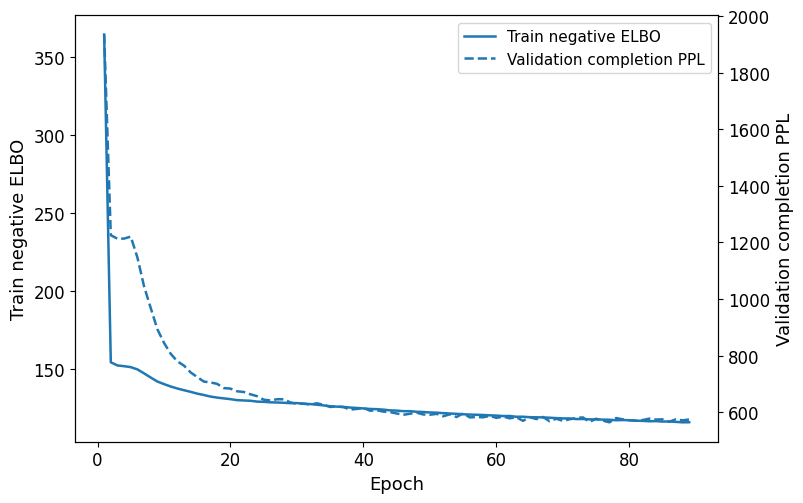

In [ ]:

selection_rows = []
if RUN_NBVAE_GRID:
    print("Running NB-VAE validation grid")
    for cfg_id, cfg in enumerate(NBVAE_GRID):
        run_seed = SEED + 100 + cfg_id
        reset_all_seeds(run_seed)
        print("\nGrid config", cfg_id, cfg)
        model = build_model('nbvae', cfg)
        _, hist, summ = train_neural_model(
            model, f'NB-VAE-grid-{cfg_id}', X_train_dense, X_val_obs_dense, X_val_obs, X_val_hold,
            lr=cfg['lr'], max_epochs=min(80, MAX_EPOCHS), patience=8,
            save_path=os.path.join(MODEL_DIR, f'nbvae_grid_{cfg_id}.pt'),
            seed=run_seed,
        )
        row = {'cfg_id': cfg_id, **cfg, **summ}
        selection_rows.append(row)
    selection_df = pd.DataFrame(selection_rows)
    selection_df.to_csv(os.path.join(TABLE_DIR, 'nbvae_grid_selection.csv'), index=False)
    best_row = selection_df.sort_values('best_val_ppl').iloc[0]
    h_enc = best_row['h_enc'] if isinstance(best_row['h_enc'], (list, tuple)) else DEFAULT_CONFIG['h_enc']
    selected_config = {
        'latent_dim': int(best_row['latent_dim']),
        'h_enc': tuple(h_enc),
        'dropout': float(best_row['dropout']),
        'lr': float(best_row['lr']),
    }
else:
    selection_df = pd.DataFrame()
    selected_config = DEFAULT_CONFIG.copy()

print("Selected neural configuration:", selected_config)

neural_models = {}
neural_histories = {}
neural_summaries = []

for model_idx, (kind, display) in enumerate([('nbvae', 'NB-to-Bernoulli VAE'), ('bernvae', 'Direct Bernoulli VAE'), ('prodlda', 'ProdLDA')]):
    run_seed = SEED + 1000 + model_idx
    reset_all_seeds(run_seed)
    print("\nTraining final", display)
    model = build_model(kind, selected_config)
    model_path = os.path.join(MODEL_DIR, f'{kind}_best.pt')
    model, hist, summ = train_neural_model(
        model, display, X_train_dense, X_val_obs_dense, X_val_obs, X_val_hold,
        lr=selected_config['lr'], max_epochs=MAX_EPOCHS, patience=PATIENCE,
        save_path=model_path,
        seed=run_seed,
    )
    neural_models[display] = model
    neural_histories[display] = hist
    neural_summaries.append(summ)

pd.DataFrame(neural_summaries).to_csv(os.path.join(TABLE_DIR, 'neural_model_selection.csv'), index=False)

# Figure 1: training curve for the selected NB-VAE.
hist_nb = neural_histories['NB-to-Bernoulli VAE']
fig, ax1 = plt.subplots(figsize=(8.2, 5.2))
ax1.plot(hist_nb['epoch'], hist_nb['train_loss'], label='Train negative ELBO', linewidth=1.8)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train negative ELBO')
style_axis(ax1)
ax2 = ax1.twinx()
ax2.plot(hist_nb['epoch'], hist_nb['val_ppl'], linestyle='--', label='Validation completion PPL', linewidth=1.8)
ax2.set_ylabel('Validation completion PPL')
style_axis(ax2)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=FIG_LEGEND_SIZE)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'training_curves_nbvae.png'), dpi=300, bbox_inches='tight')
plt.show()


## 9. Document-completion and calibration evaluation for neural models

This cell evaluates the three neural models on the held-out test set using the fixed completion mask.

In [ ]:

completion_rows = []
calibration_rows = []
calibration_bins_all = []
test_score_cache = {}

for display, model in neural_models.items():
    print("Predicting test scores for", display)
    scores = predict_in_batches(model, X_test_obs_dense)
    test_score_cache[display] = scores
    completion_rows.append(evaluate_completion_scores(scores, X_test_obs, X_test_hold, display))
    # ProdLDA outputs a categorical word distribution, so calibration as term presence is not reported.
    if display != 'ProdLDA':
        c_metrics, c_bins = calibration_metrics(scores, X_test_obs, X_test_hold, display)
        calibration_rows.append(c_metrics)
        calibration_bins_all.append(c_bins)

completion_df = pd.DataFrame(completion_rows)
calibration_df = pd.DataFrame(calibration_rows)
calibration_bins_df = pd.concat(calibration_bins_all, ignore_index=True) if calibration_bins_all else pd.DataFrame()
completion_df.to_csv(os.path.join(TABLE_DIR, 'completion_metrics_neural.csv'), index=False)
calibration_df.to_csv(os.path.join(TABLE_DIR, 'calibration_metrics_neural.csv'), index=False)
calibration_bins_df.to_csv(os.path.join(TABLE_DIR, 'calibration_bins_neural.csv'), index=False)
print(completion_df)
print(calibration_df)


Predicting test scores for NB-to-Bernoulli VAE
Predicting test scores for Direct Bernoulli VAE
Predicting test scores for ProdLDA
                  model       P@5      P@10      P@20       R@5      R@10  \
0   NB-to-Bernoulli VAE  0.347031  0.268426  0.199717  0.114936  0.176114   
1  Direct Bernoulli VAE  0.367012  0.284354  0.212771  0.121919  0.186096   
2               ProdLDA  0.252215  0.191140  0.142460  0.083131  0.125846   

       R@20    nDCG@5   nDCG@10   nDCG@20         PPL  
0  0.257419  0.383126  0.320578  0.299590  582.895490  
1  0.273649  0.402233  0.337696  0.316979  531.088632  
2  0.186033  0.285190  0.233788  0.218251  987.469727  
                  model       ECE     Brier
0   NB-to-Bernoulli VAE  0.001685  0.003411
1  Direct Bernoulli VAE  0.001641  0.003356


## 10. Unigram and TF-IDF nearest-neighbour baselines

The unigram prior is a document-independent popularity baseline. The TF-IDF baseline uses nearest neighbours from the training set and averages their binary term-presence vectors.

In [ ]:

def repeat_row(row: np.ndarray, n: int) -> np.ndarray:
    return np.broadcast_to(row.reshape(1, -1), (n, row.size)).copy()


def knn_term_scores_from_sparse(train_repr, query_repr, X_train_binary: sp.csr_matrix, k: int = 30, batch_size: int = 128) -> np.ndarray:
    nn = NearestNeighbors(n_neighbors=min(k, X_train_binary.shape[0]), metric='cosine')
    nn.fit(train_repr)
    all_scores = []
    for start in tqdm(range(0, query_repr.shape[0], batch_size), desc='KNN term scores'):
        q = query_repr[start:start+batch_size]
        dist, idx = nn.kneighbors(q, return_distance=True)
        sim = np.maximum(1.0 - dist, 0.0) + 1e-6
        for weights, neigh in zip(sim, idx):
            weights = weights / weights.sum()
            neigh_matrix = X_train_binary[neigh].astype(np.float32)
            score = np.asarray(weights @ neigh_matrix).ravel()
            all_scores.append(score.astype(np.float32))
    return np.vstack(all_scores)

# Unigram raw presence rates from training documents
unigram_raw = np.asarray(X_train.mean(axis=0)).ravel().astype(np.float32)
unigram_scores = repeat_row(np.clip(unigram_raw, 1e-7, 1.0 - 1e-7), X_test.shape[0])
completion_rows.append(evaluate_completion_scores(unigram_scores, X_test_obs, X_test_hold, 'Unigram prior'))
c_metrics, c_bins = calibration_metrics(unigram_scores, X_test_obs, X_test_hold, 'Unigram prior')
calibration_rows.append(c_metrics)
calibration_bins_all.append(c_bins)
test_score_cache['Unigram prior'] = unigram_scores

# TF-IDF nearest-neighbour completion
print("Computing TF-IDF nearest-neighbour baseline")
tfidf_transformer = TfidfTransformer(norm='l2', use_idf=True, smooth_idf=True)
X_train_tfidf = tfidf_transformer.fit_transform(X_train)
X_test_obs_tfidf = tfidf_transformer.transform(X_test_obs)
tfidf_scores = knn_term_scores_from_sparse(X_train_tfidf, X_test_obs_tfidf, X_train, k=KNN_K)
completion_rows.append(evaluate_completion_scores(tfidf_scores, X_test_obs, X_test_hold, 'TF-IDF nearest neighbours'))
c_metrics, c_bins = calibration_metrics(tfidf_scores, X_test_obs, X_test_hold, 'TF-IDF nearest neighbours')
calibration_rows.append(c_metrics)
calibration_bins_all.append(c_bins)
test_score_cache['TF-IDF nearest neighbours'] = tfidf_scores

completion_df = pd.DataFrame(completion_rows)
calibration_df = pd.DataFrame(calibration_rows)
calibration_bins_df = pd.concat(calibration_bins_all, ignore_index=True) if calibration_bins_all else pd.DataFrame()
completion_df.to_csv(os.path.join(TABLE_DIR, 'completion_metrics_with_simple_baselines.csv'), index=False)
calibration_df.to_csv(os.path.join(TABLE_DIR, 'calibration_metrics_with_simple_baselines.csv'), index=False)
calibration_bins_df.to_csv(os.path.join(TABLE_DIR, 'calibration_bins_with_simple_baselines.csv'), index=False)
print(completion_df)
print(calibration_df)


Computing TF-IDF nearest-neighbour baseline


KNN term scores:   0%|          | 0/9 [00:00<?, ?it/s]

                       model       P@5      P@10      P@20       R@5  \
0        NB-to-Bernoulli VAE  0.347031  0.268426  0.199717  0.114936   
1       Direct Bernoulli VAE  0.367012  0.284354  0.212771  0.121919   
2                    ProdLDA  0.252215  0.191140  0.142460  0.083131   
3              Unigram prior  0.243921  0.184166  0.135627  0.079533   
4  TF-IDF nearest neighbours  0.550801  0.477945  0.381668  0.186111   

       R@10      R@20    nDCG@5   nDCG@10   nDCG@20          PPL  
0  0.176114  0.257419  0.383126  0.320578  0.299590   582.895490  
1  0.186096  0.273649  0.402233  0.337696  0.316979   531.088632  
2  0.125846  0.186033  0.285190  0.233788  0.218251   987.469727  
3  0.120978  0.176454  0.278008  0.227098  0.209973  1101.840586  
4  0.317135  0.490095  0.583859  0.529687  0.525084  2695.355591  
                       model       ECE     Brier
0        NB-to-Bernoulli VAE  0.001685  0.003411
1       Direct Bernoulli VAE  0.001641  0.003356
2              Uni

## 11. Patent transformer nearest-neighbour baseline

The default is PatentSBERTa. The query text for test documents is a pseudo-abstract formed only from the observed completion terms, which prevents held-out terms from leaking into the embedding.

In [ ]:

def observed_terms_to_texts(X_obs: sp.csr_matrix, vocab: np.ndarray, max_terms: Optional[int] = None) -> List[str]:
    texts = []
    X_obs = X_obs.tocsr()
    for i in range(X_obs.shape[0]):
        idx = X_obs.getrow(i).indices
        if max_terms is not None and idx.size > max_terms:
            idx = idx[:max_terms]
        text = ' '.join(vocab[idx].tolist())
        texts.append(text if text.strip() else 'empty')
    return texts


def encode_sentence_transformer(model_name: str, texts: List[str], cache_name: str, batch_size: int = 32) -> Optional[np.ndarray]:
    cache_path = os.path.join(OUT_DIR, cache_name)
    if os.path.exists(cache_path):
        print(f"Loading cached embeddings: {cache_path}")
        return np.load(cache_path)
    try:
        from sentence_transformers import SentenceTransformer
        print(f"Loading sentence-transformer model: {model_name}")
        st_model = SentenceTransformer(model_name, device=str(DEVICE))
        emb = st_model.encode(texts, batch_size=batch_size, show_progress_bar=True, normalize_embeddings=True)
        emb = np.asarray(emb, dtype=np.float32)
        np.save(cache_path, emb)
        return emb
    except Exception as exc:
        print(f"Transformer baseline skipped because embeddings could not be computed: {exc}")
        return None

if RUN_TRANSFORMER_BASELINE:
    train_texts_full = splits['train']['raw_text'].fillna('').astype(str).tolist()
    test_texts_observed = observed_terms_to_texts(X_test_obs, vocab, max_terms=256)
    train_emb = encode_sentence_transformer(TRANSFORMER_MODEL_NAME, train_texts_full, 'patent_transformer_train_embeddings.npy')
    test_obs_emb = encode_sentence_transformer(TRANSFORMER_MODEL_NAME, test_texts_observed, 'patent_transformer_test_observed_embeddings.npy')
    if train_emb is not None and test_obs_emb is not None:
        transformer_scores = knn_term_scores_from_sparse(train_emb, test_obs_emb, X_train, k=KNN_K)
        t_name = 'Patent transformer nearest neighbours'
        completion_rows.append(evaluate_completion_scores(transformer_scores, X_test_obs, X_test_hold, t_name))
        c_metrics, c_bins = calibration_metrics(transformer_scores, X_test_obs, X_test_hold, t_name)
        calibration_rows.append(c_metrics)
        calibration_bins_all.append(c_bins)
        test_score_cache[t_name] = transformer_scores
else:
    train_emb = None
    test_obs_emb = None

if RUN_OPTIONAL_PAECTER:
    train_texts_full = splits['train']['raw_text'].fillna('').astype(str).tolist()
    test_texts_observed = observed_terms_to_texts(X_test_obs, vocab, max_terms=256)
    train_emb_paecter = encode_sentence_transformer(PAECTER_MODEL_NAME, train_texts_full, 'paecter_train_embeddings.npy', batch_size=16)
    test_obs_emb_paecter = encode_sentence_transformer(PAECTER_MODEL_NAME, test_texts_observed, 'paecter_test_observed_embeddings.npy', batch_size=16)
    if train_emb_paecter is not None and test_obs_emb_paecter is not None:
        paecter_scores = knn_term_scores_from_sparse(train_emb_paecter, test_obs_emb_paecter, X_train, k=KNN_K)
        p_name = 'PaECTER nearest neighbours'
        completion_rows.append(evaluate_completion_scores(paecter_scores, X_test_obs, X_test_hold, p_name))
        c_metrics, c_bins = calibration_metrics(paecter_scores, X_test_obs, X_test_hold, p_name)
        calibration_rows.append(c_metrics)
        calibration_bins_all.append(c_bins)
        test_score_cache[p_name] = paecter_scores

completion_df = pd.DataFrame(completion_rows).drop_duplicates('model', keep='last')
calibration_df = pd.DataFrame(calibration_rows).drop_duplicates('model', keep='last')
calibration_bins_df = pd.concat(calibration_bins_all, ignore_index=True) if calibration_bins_all else pd.DataFrame()
completion_df.to_csv(os.path.join(TABLE_DIR, 'completion_metrics_all.csv'), index=False)
calibration_df.to_csv(os.path.join(TABLE_DIR, 'calibration_metrics_all.csv'), index=False)
calibration_bins_df.to_csv(os.path.join(TABLE_DIR, 'calibration_bins_all.csv'), index=False)
print(completion_df.sort_values('nDCG@5', ascending=False))
print(calibration_df.sort_values('ECE'))


Loading cached embeddings: /content/drive/MyDrive/Colab Notebooks/Patents_Adventure/preprocessed/patent_transformer_train_embeddings.npy
Loading cached embeddings: /content/drive/MyDrive/Colab Notebooks/Patents_Adventure/preprocessed/patent_transformer_test_observed_embeddings.npy


KNN term scores:   0%|          | 0/9 [00:00<?, ?it/s]

Loading sentence-transformer model: mpi-inno-comp/paecter


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

...

Loading sentence-transformer model: mpi-inno-comp/paecter


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Batches:   0%|          | 0/67 [00:00<?, ?it/s]

KNN term scores:   0%|          | 0/9 [00:00<?, ?it/s]

                                   model       P@5      P@10      P@20  \
4              TF-IDF nearest neighbours  0.550801  0.477945  0.381668   
1                   Direct Bernoulli VAE  0.367012  0.284354  0.212771   
6             PaECTER nearest neighbours  0.348351  0.268332  0.203393   
0                    NB-to-Bernoulli VAE  0.347031  0.268426  0.199717   
5  Patent transformer nearest neighbours  0.337606  0.268332  0.205042   
2                                ProdLDA  0.252215  0.191140  0.142460   
3                          Unigram prior  0.243921  0.184166  0.135627   

        R@5      R@10      R@20    nDCG@5   nDCG@10   nDCG@20           PPL  
4  0.186111  0.317135  0.490095  0.583859  0.529687  0.525084   2695.355591  
1  0.121919  0.186096  0.273649  0.402233  0.337696  0.316979    531.088632  
6  0.116143  0.176192  0.263609  0.386491  0.322042  0.304943  14121.000688  
0  0.114936  0.176114  0.257419  0.383126  0.320578  0.299590    582.895490  
5  0.115515  0.18

## 12. Completion, calibration and additional reviewer-facing diagnostics

The first two figures reproduce the core manuscript comparisons. The additional rank-recovery and frequency-stratified calibration figures are useful for the appendix or, if space allows, the main text because they show whether conclusions are stable across ranking cut-offs and term-frequency strata.


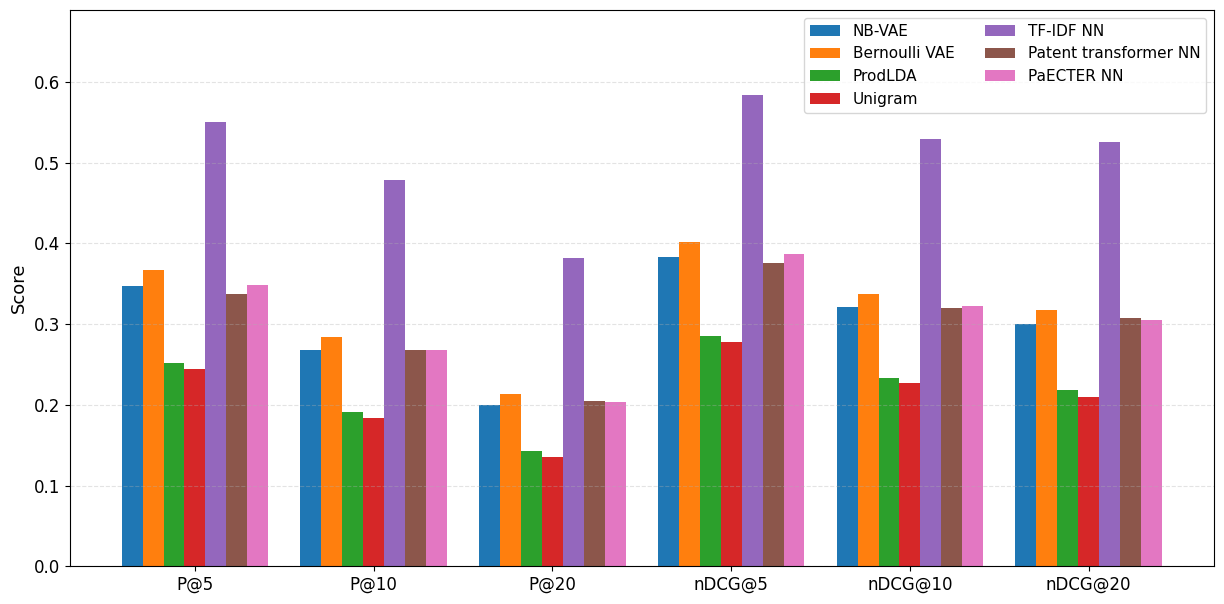

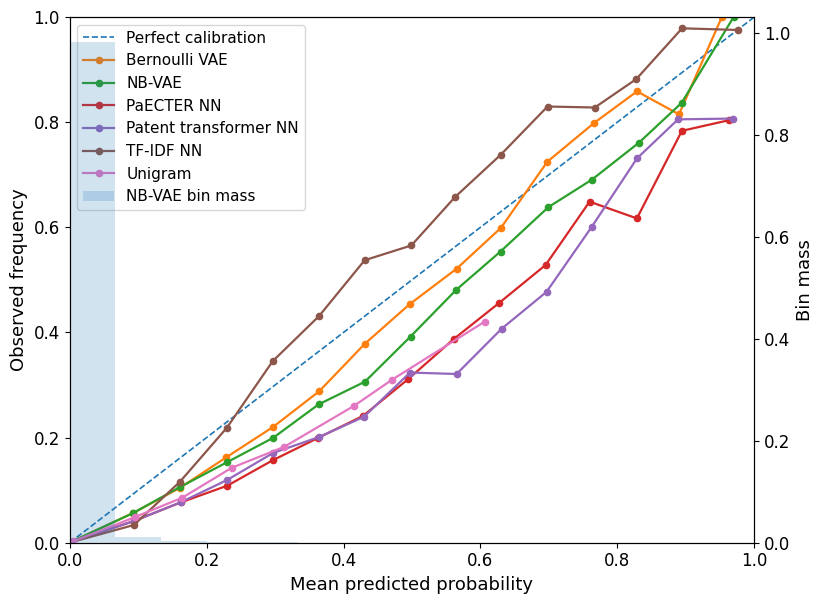

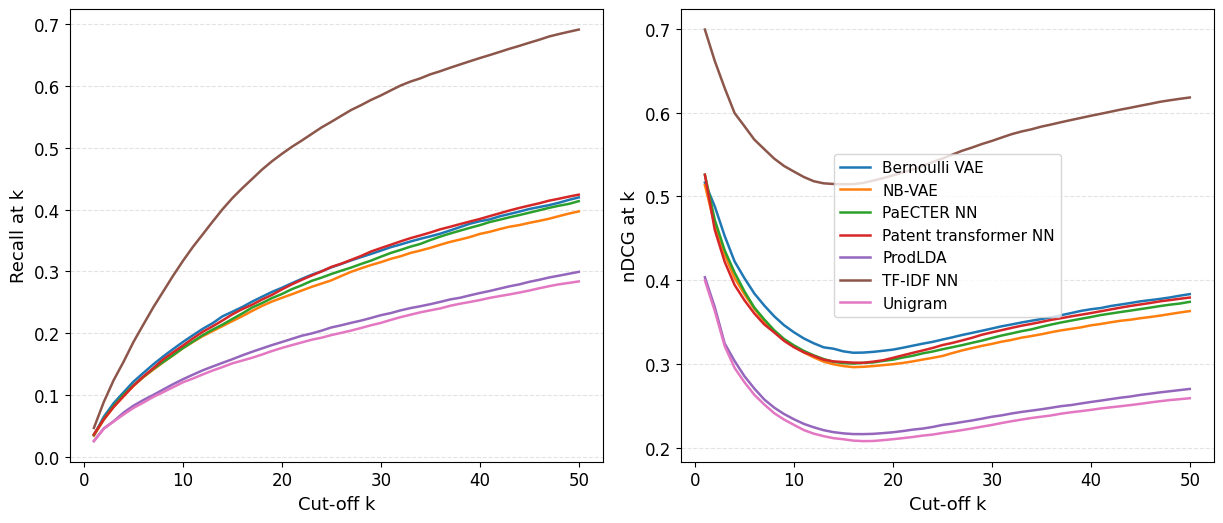

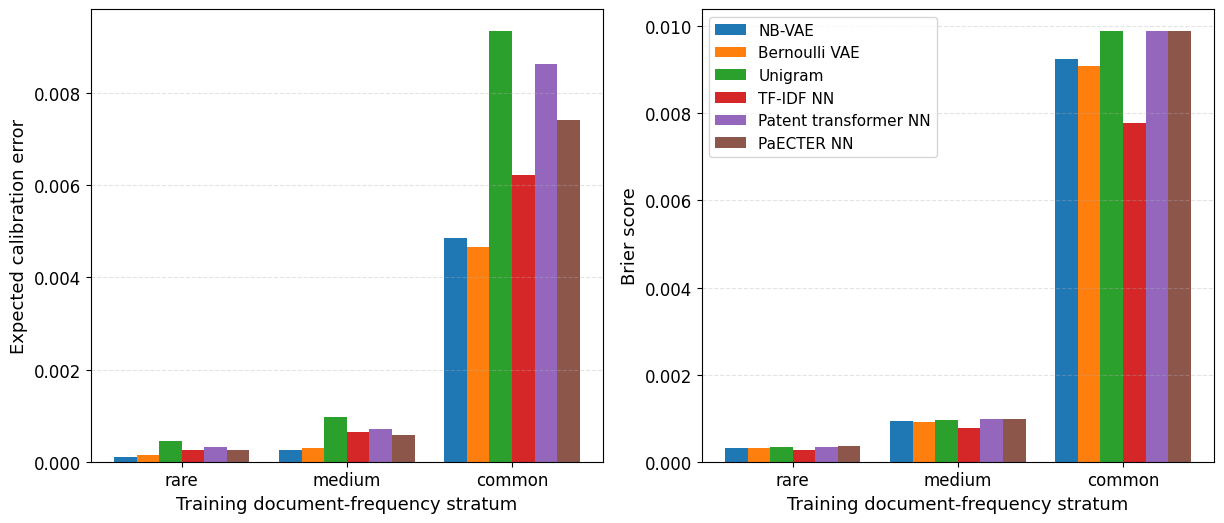

In [ ]:

def plot_completion_metrics(df: pd.DataFrame, out_path: str):
    metrics = ['P@5', 'P@10', 'P@20', 'nDCG@5', 'nDCG@10', 'nDCG@20']
    available = [m for m in metrics if m in df.columns]
    labels = df['model'].tolist()
    x = np.arange(len(available))
    width = 0.82 / max(1, len(labels))
    fig, ax = plt.subplots(figsize=(12.4, 6.2))
    for j, (_, row) in enumerate(df.iterrows()):
        vals = [row[m] for m in available]
        ax.bar(x + (j - (len(labels)-1)/2) * width, vals, width=width, label=short_name(row['model']))
    ax.set_xticks(x)
    ax.set_xticklabels(available, rotation=0)
    ax.set_ylabel('Score')
    ax.set_ylim(0, max(0.05, np.nanmax(df[available].values) * 1.18))
    ax.legend(fontsize=FIG_LEGEND_SIZE, ncol=2, frameon=True)
    style_axis(ax, grid_axis='y')
    fig.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()


def plot_calibration_bins(bins_df: pd.DataFrame, out_path: str):
    fig, ax1 = plt.subplots(figsize=(8.4, 6.2))
    ax1.plot([0, 1], [0, 1], linestyle='--', linewidth=1.2, label='Perfect calibration')
    for model_name, group in bins_df.groupby('model'):
        g = group.dropna(subset=['freq'])
        if g.empty:
            continue
        ax1.plot(g['conf'], g['freq'], marker='o', markersize=4.5, linewidth=1.6, label=short_name(model_name))
    ax1.set_xlabel('Mean predicted probability')
    ax1.set_ylabel('Observed frequency')
    max_conf = bins_df['conf'].max(skipna=True) if not bins_df.empty else 1.0
    max_freq = bins_df['freq'].max(skipna=True) if not bins_df.empty else 1.0
    ax1.set_xlim(0, min(1.0, max(0.05, max_conf * 1.2)))
    ax1.set_ylim(0, min(1.0, max(0.05, max_freq * 1.2)))
    style_axis(ax1)
    ax2 = ax1.twinx()
    nb_bins = bins_df[bins_df['model'].eq('NB-to-Bernoulli VAE')]
    if not nb_bins.empty:
        ax2.bar(nb_bins['mid'], nb_bins['mass'], width=1/15, alpha=0.20, label='NB-VAE bin mass')
    ax2.set_ylabel('Bin mass')
    style_axis(ax2)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=FIG_LEGEND_SIZE, loc='best', frameon=True)
    fig.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()


def evaluate_completion_curve(scores: np.ndarray, X_obs: sp.csr_matrix, X_hold: sp.csr_matrix, model_name: str, curve_ks: Tuple[int, ...] = CURVE_KS) -> pd.DataFrame:
    """Compute P@k, R@k and nDCG@k for many k values using stable ranking ties."""
    scores = np.asarray(scores, dtype=np.float64)
    X_obs = X_obs.tocsr(); X_hold = X_hold.tocsr()
    max_k = max(curve_ks)
    accum = {k: {'P': [], 'R': [], 'nDCG': []} for k in curve_ks}
    for i in range(scores.shape[0]):
        held_idx = X_hold.getrow(i).indices
        if held_idx.size == 0:
            continue
        obs_idx = X_obs.getrow(i).indices
        rank_scores = scores[i].copy()
        rank_scores[obs_idx] = -np.inf
        order = np.argsort(-rank_scores, kind='mergesort')[:max_k]
        gains = np.isin(order, held_idx).astype(np.float64)
        total_pos = held_idx.size
        cumsum = np.cumsum(gains)
        discounts = 1.0 / np.log2(np.arange(2, max_k + 2))
        dcg_cumsum = np.cumsum(gains * discounts)
        for k in curve_ks:
            ideal_len = min(k, total_pos)
            ideal = np.sum(1.0 / np.log2(np.arange(2, ideal_len + 2))) if ideal_len > 0 else 0.0
            accum[k]['P'].append(float(cumsum[k-1] / k))
            accum[k]['R'].append(float(cumsum[k-1] / total_pos))
            accum[k]['nDCG'].append(float(dcg_cumsum[k-1] / ideal if ideal > 0 else 0.0))
    rows = []
    for k in curve_ks:
        rows.append({
            'model': model_name,
            'k': k,
            'P@k': float(np.mean(accum[k]['P'])) if accum[k]['P'] else np.nan,
            'R@k': float(np.mean(accum[k]['R'])) if accum[k]['R'] else np.nan,
            'nDCG@k': float(np.mean(accum[k]['nDCG'])) if accum[k]['nDCG'] else np.nan,
        })
    return pd.DataFrame(rows)


def plot_completion_curves(curve_df: pd.DataFrame, out_path: str):
    fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.4), sharex=True)
    for model_name, group in curve_df.groupby('model'):
        g = group.sort_values('k')
        axes[0].plot(g['k'], g['R@k'], linewidth=1.8, label=short_name(model_name))
        axes[1].plot(g['k'], g['nDCG@k'], linewidth=1.8, label=short_name(model_name))
    axes[0].set_xlabel('Cut-off k')
    axes[0].set_ylabel('Recall at k')
    axes[1].set_xlabel('Cut-off k')
    axes[1].set_ylabel('nDCG at k')
    for ax in axes:
        style_axis(ax, grid_axis='y')
    axes[1].legend(fontsize=FIG_LEGEND_SIZE, loc='best', frameon=True)
    fig.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()


def collect_unobserved_by_frequency(probs: np.ndarray, X_obs: sp.csr_matrix, X_hold: sp.csr_matrix, term_strata: np.ndarray, model_name: str, n_bins: int = 15) -> pd.DataFrame:
    """Compute calibration metrics separately for rare, medium and common training terms."""
    probs = np.asarray(probs, dtype=np.float64)
    X_obs = X_obs.tocsr(); X_hold = X_hold.tocsr()
    strata_names = pd.Series(term_strata).dropna().unique().tolist()
    rows = []
    V = probs.shape[1]
    for stratum in strata_names:
        all_p, all_y = [], []
        stratum_mask = (term_strata == stratum)
        for i in range(probs.shape[0]):
            obs_idx = X_obs.getrow(i).indices
            mask = stratum_mask.copy()
            mask[obs_idx] = False
            if not mask.any():
                continue
            y = np.zeros(V, dtype=np.float32)
            y[X_hold.getrow(i).indices] = 1.0
            all_p.append(probs[i, mask])
            all_y.append(y[mask])
        if not all_p:
            continue
        p = np.clip(np.concatenate(all_p), 0.0, 1.0)
        y = np.concatenate(all_y)
        bins = np.linspace(0, 1, n_bins + 1)
        ece = 0.0
        for b in range(n_bins):
            lo, hi = bins[b], bins[b + 1]
            m = (p >= lo) & ((p < hi) if b < n_bins - 1 else (p <= hi))
            if m.sum() == 0:
                continue
            ece += float(m.mean()) * abs(float(y[m].mean()) - float(p[m].mean()))
        rows.append({
            'model': model_name,
            'frequency_stratum': stratum,
            'ECE': float(ece),
            'Brier': float(np.mean((p - y) ** 2)),
            'positive_rate': float(y.mean()),
            'evaluated_pairs': int(p.size),
        })
    return pd.DataFrame(rows)


def plot_frequency_calibration(strata_df: pd.DataFrame, out_path: str):
    if strata_df.empty:
        return
    order = ['rare', 'medium', 'common']
    strata = [s for s in order if s in strata_df['frequency_stratum'].unique()]
    models = [m for m in completion_df['model'].tolist() if m in strata_df['model'].unique()]
    x = np.arange(len(strata))
    width = 0.82 / max(1, len(models))
    fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.4), sharex=True)
    for j, model_name in enumerate(models):
        subset = strata_df[strata_df['model'].eq(model_name)]
        for ax, metric in zip(axes, ['ECE', 'Brier']):
            vals = []
            for s in strata:
                row = subset[subset['frequency_stratum'].eq(s)]
                vals.append(float(row[metric].iloc[0]) if not row.empty else np.nan)
            ax.bar(x + (j - (len(models)-1)/2) * width, vals, width=width, label=short_name(model_name))
    axes[0].set_ylabel('Expected calibration error')
    axes[1].set_ylabel('Brier score')
    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(strata)
        ax.set_xlabel('Training document-frequency stratum')
        style_axis(ax, grid_axis='y')
    axes[1].legend(fontsize=FIG_LEGEND_SIZE, ncol=1, frameon=True)
    fig.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()

# Main manuscript figures.
plot_completion_metrics(completion_df, os.path.join(FIG_DIR, 'completion_metrics_models.png'))
plot_calibration_bins(calibration_bins_df, os.path.join(FIG_DIR, 'calibration_reliability_models.png'))

# Additional Figure A: rank-recovery curves across cut-offs.
curve_models = [m for m in completion_df['model'].tolist() if m in test_score_cache]
completion_curve_df = pd.concat(
    [evaluate_completion_curve(test_score_cache[m], X_test_obs, X_test_hold, m) for m in curve_models],
    ignore_index=True,
)
completion_curve_df.to_csv(os.path.join(TABLE_DIR, 'completion_rank_curves.csv'), index=False)
plot_completion_curves(completion_curve_df, os.path.join(FIG_DIR, 'completion_rank_curves.png'))

# Additional Figure B: calibration by training document-frequency stratum.
term_counts = np.asarray(X_train.sum(axis=0)).ravel()
try:
    term_strata = np.asarray(pd.qcut(term_counts, q=3, labels=['rare', 'medium', 'common'], duplicates='drop').astype(str))
except Exception:
    # Fallback if there are too many tied counts for qcut.
    tertiles = np.quantile(term_counts, [1/3, 2/3])
    term_strata = np.where(term_counts <= tertiles[0], 'rare', np.where(term_counts <= tertiles[1], 'medium', 'common'))
calibration_models_for_strata = [m for m in completion_df['model'].tolist() if m in test_score_cache and m != 'ProdLDA']
strata_calibration_df = pd.concat(
    [collect_unobserved_by_frequency(test_score_cache[m], X_test_obs, X_test_hold, term_strata, m) for m in calibration_models_for_strata],
    ignore_index=True,
)
strata_calibration_df.to_csv(os.path.join(TABLE_DIR, 'frequency_stratified_calibration.csv'), index=False)
plot_frequency_calibration(strata_calibration_df, os.path.join(FIG_DIR, 'calibration_by_frequency_stratum.png'))


## 13. Downstream CPC-prefix retrieval

This task asks whether each representation helps retrieve patents with a target CPC prefix. The bar chart reports average precision by representation, while the precision-recall curves expose the full ranking trade-off and are more informative than a single threshold for imbalanced CPC labels.


Loading cached embeddings: /content/drive/MyDrive/Colab Notebooks/Patents_Adventure/preprocessed/patent_transformer_train_full_embeddings.npy
Loading cached embeddings: /content/drive/MyDrive/Colab Notebooks/Patents_Adventure/preprocessed/patent_transformer_test_full_embeddings.npy
B01D53/04 train positives 2194 test positives 274
B01D53/62 train positives 2231 test positives 279
  target_prefix             representation     AUROC  Average precision  \
3     B01D53/04                 TF-IDF SVD  0.902336           0.795316   
4     B01D53/04         Patent transformer  0.898909           0.773639   
1     B01D53/04  Bernoulli VAE latent mean  0.835562           0.676537   
0     B01D53/04         NB-VAE latent mean  0.796645           0.626313   
2     B01D53/04  ProdLDA topic proportions  0.507656           0.307615   
9     B01D53/62         Patent transformer  0.832602           0.623820   
8     B01D53/62                 TF-IDF SVD  0.813943           0.622297   
5     B01D53/62  

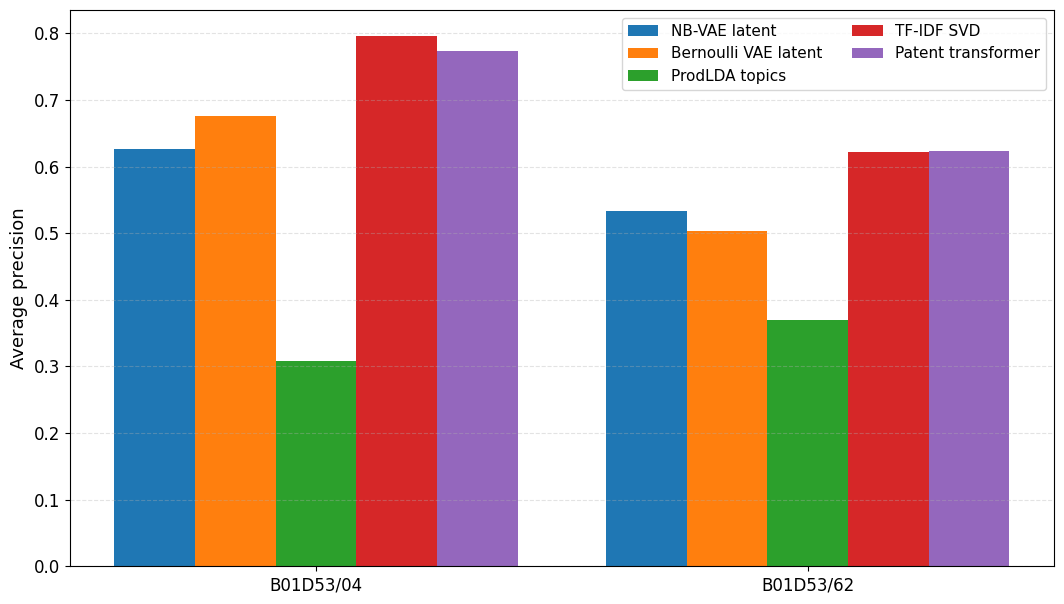

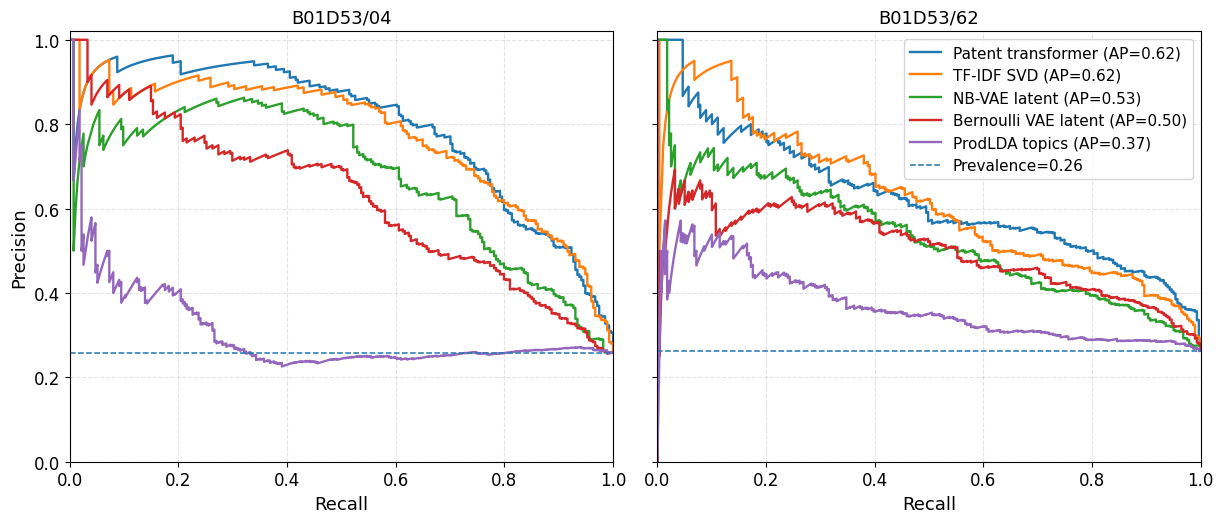

In [ ]:

def labels_for_split(split_name: str, prefix: str) -> np.ndarray:
    safe = prefix.replace('/', '_').replace('.', '_')
    col = f'label_{safe}'
    return splits[split_name][col].astype(int).to_numpy()


def eval_logistic_retrieval(Xtr, Xte, ytr, yte, representation: str, target_prefix: str) -> Optional[Tuple[Dict[str, float], np.ndarray]]:
    if len(np.unique(ytr)) < 2 or len(np.unique(yte)) < 2:
        return None
    clf = LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear', random_state=SEED)
    clf.fit(Xtr, ytr)
    if hasattr(clf, 'predict_proba'):
        score = clf.predict_proba(Xte)[:, 1]
    else:
        score = clf.decision_function(Xte)
    row = {
        'target_prefix': target_prefix,
        'representation': representation,
        'AUROC': float(roc_auc_score(yte, score)),
        'Average precision': float(average_precision_score(yte, score)),
        'P@100': precision_at_n(yte, score, n=100),
        'test_positives': int(yte.sum()),
        'test_total': int(len(yte)),
    }
    return row, np.asarray(score, dtype=np.float64)

# Build full-document representations for train and test.
reprs_train = {}
reprs_test = {}
reprs_train['NB-VAE latent mean'] = encode_in_batches(neural_models['NB-to-Bernoulli VAE'], X_train_dense)
reprs_test['NB-VAE latent mean'] = encode_in_batches(neural_models['NB-to-Bernoulli VAE'], X_test_dense)
reprs_train['Bernoulli VAE latent mean'] = encode_in_batches(neural_models['Direct Bernoulli VAE'], X_train_dense)
reprs_test['Bernoulli VAE latent mean'] = encode_in_batches(neural_models['Direct Bernoulli VAE'], X_test_dense)
reprs_train['ProdLDA topic proportions'] = encode_in_batches(neural_models['ProdLDA'], X_train_dense)
reprs_test['ProdLDA topic proportions'] = encode_in_batches(neural_models['ProdLDA'], X_test_dense)

# Dense TF-IDF-SVD representation for a fair low-dimensional classifier.
svd = TruncatedSVD(n_components=min(50, X_train_tfidf.shape[1]-1), random_state=SEED)
reprs_train['TF-IDF SVD'] = svd.fit_transform(X_train_tfidf)
reprs_test['TF-IDF SVD'] = svd.transform(tfidf_transformer.transform(X_test))

# Transformer full-abstract embeddings for downstream retrieval if available.
if RUN_TRANSFORMER_BASELINE:
    train_texts_full = splits['train']['raw_text'].fillna('').astype(str).tolist()
    test_texts_full = splits['test']['raw_text'].fillna('').astype(str).tolist()
    train_full_emb = encode_sentence_transformer(TRANSFORMER_MODEL_NAME, train_texts_full, 'patent_transformer_train_full_embeddings.npy')
    test_full_emb = encode_sentence_transformer(TRANSFORMER_MODEL_NAME, test_texts_full, 'patent_transformer_test_full_embeddings.npy')
    if train_full_emb is not None and test_full_emb is not None:
        reprs_train['Patent transformer'] = train_full_emb
        reprs_test['Patent transformer'] = test_full_emb

retrieval_rows = []
retrieval_score_records = {}
for prefix in DOWNSTREAM_PREFIXES:
    ytr = labels_for_split('train', prefix)
    yte = labels_for_split('test', prefix)
    print(prefix, 'train positives', ytr.sum(), 'test positives', yte.sum())
    for rep_name in reprs_train:
        result = eval_logistic_retrieval(reprs_train[rep_name], reprs_test[rep_name], ytr, yte, rep_name, prefix)
        if result is not None:
            row, score = result
            retrieval_rows.append(row)
            retrieval_score_records[(prefix, rep_name)] = {'y_true': yte, 'score': score}

retrieval_df = pd.DataFrame(retrieval_rows)
retrieval_df.to_csv(os.path.join(TABLE_DIR, 'cpc_retrieval_metrics.csv'), index=False)
print(retrieval_df.sort_values(['target_prefix', 'Average precision'], ascending=[True, False]))

# Figure 4: average precision by representation and target prefix.
fig, ax = plt.subplots(figsize=(10.8, 6.2))
if not retrieval_df.empty:
    reps = retrieval_df['representation'].unique().tolist()
    prefixes = retrieval_df['target_prefix'].unique().tolist()
    x = np.arange(len(prefixes))
    width = 0.82 / len(reps)
    for j, rep in enumerate(reps):
        vals = []
        for prefix in prefixes:
            sub = retrieval_df[(retrieval_df['target_prefix'] == prefix) & (retrieval_df['representation'] == rep)]
            vals.append(float(sub['Average precision'].iloc[0]) if not sub.empty else np.nan)
        ax.bar(x + (j - (len(reps)-1)/2) * width, vals, width=width, label=short_name(rep))
    ax.set_xticks(x)
    ax.set_xticklabels(prefixes)
    ax.set_ylabel('Average precision')
    style_axis(ax, grid_axis='y')
    ax.legend(fontsize=FIG_LEGEND_SIZE, ncol=2, frameon=True)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'cpc_retrieval_metrics.png'), dpi=300, bbox_inches='tight')
plt.show()

# Additional Figure C: precision-recall curves for the downstream CPC retrieval task.
def plot_cpc_precision_recall_curves(records: Dict[Tuple[str, str], Dict[str, np.ndarray]], retrieval_df: pd.DataFrame, out_path: str):
    if not records:
        return
    prefixes = retrieval_df['target_prefix'].unique().tolist()
    fig, axes = plt.subplots(1, len(prefixes), figsize=(6.2 * len(prefixes), 5.4), sharey=True)
    if len(prefixes) == 1:
        axes = [axes]
    for ax, prefix in zip(axes, prefixes):
        sub = retrieval_df[retrieval_df['target_prefix'].eq(prefix)].sort_values('Average precision', ascending=False)
        # Plot all available representations. If the legend becomes crowded, use the table to select the top rows for the paper.
        for _, row in sub.iterrows():
            rep = row['representation']
            rec = records.get((prefix, rep))
            if rec is None:
                continue
            precision, recall, _ = precision_recall_curve(rec['y_true'], rec['score'])
            ap = average_precision_score(rec['y_true'], rec['score'])
            ax.plot(recall, precision, linewidth=1.7, label=f"{short_name(rep)} (AP={ap:.2f})")
        baseline = sub['test_positives'].iloc[0] / sub['test_total'].iloc[0]
        ax.axhline(baseline, linestyle='--', linewidth=1.1, label=f'Prevalence={baseline:.2f}')
        ax.set_title(prefix)
        ax.set_xlabel('Recall')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.02)
        style_axis(ax, grid_axis='both')
    axes[0].set_ylabel('Precision')
    axes[-1].legend(fontsize=FIG_LEGEND_SIZE, loc='best', frameon=True)
    fig.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_cpc_precision_recall_curves(retrieval_score_records, retrieval_df, os.path.join(FIG_DIR, 'cpc_precision_recall_curves.png'))

# Store PR curve points for reproducibility and optional appendix use.
pr_rows = []
for (prefix, rep), rec in retrieval_score_records.items():
    precision, recall, threshold = precision_recall_curve(rec['y_true'], rec['score'])
    for idx in range(len(precision)):
        pr_rows.append({
            'target_prefix': prefix,
            'representation': rep,
            'recall': float(recall[idx]),
            'precision': float(precision[idx]),
            'threshold': float(threshold[idx]) if idx < len(threshold) else np.nan,
        })
retrieval_pr_curves_df = pd.DataFrame(pr_rows)
retrieval_pr_curves_df.to_csv(os.path.join(TABLE_DIR, 'cpc_precision_recall_curves.csv'), index=False)


## 14. Write LaTeX tables and manuscript macros

The revised manuscript imports these files. After running the notebook, upload `figuresForPaper2/` and `tablesForPaper2/` to Overleaf with the revised `.tex` file.


In [ ]:

def fmt(x, digits=3):
    if x is None or (isinstance(x, float) and not np.isfinite(x)):
        return '--'
    if isinstance(x, (int, np.integer)):
        return f"{int(x):,}"
    if isinstance(x, (float, np.floating)):
        return f"{float(x):.{digits}f}"
    return str(x)


def df_to_latex_tabular(df: pd.DataFrame, columns: List[str], align: str, path: str, digits: int = 3):
    lines = []
    lines.append('\\begin{tabular}{' + align + '}')
    lines.append('\\toprule')
    headers = [c.replace('_', ' ') for c in columns]
    lines.append(' & '.join(headers) + ' \\\\')
    lines.append('\\midrule')
    for _, row in df.iterrows():
        vals = [fmt(row[c], digits=digits) for c in columns]
        vals = [v.replace('%', '\\%') if isinstance(v, str) else v for v in vals]
        lines.append(' & '.join(vals) + ' \\\\')
    lines.append('\\bottomrule')
    lines.append('\\end{tabular}')
    Path(path).write_text('\n'.join(lines))

# Corpus stats table
corpus_stats = pd.DataFrame([
    {'Quantity': 'Documents', 'Symbol': '$M$', 'Value': f"{len(df):,}"},
    {'Quantity': 'Training documents', 'Symbol': '$M_{\\mathrm{train}}$', 'Value': f"{X_train.shape[0]:,}"},
    {'Quantity': 'Validation documents', 'Symbol': '$M_{\\mathrm{val}}$', 'Value': f"{X_val.shape[0]:,}"},
    {'Quantity': 'Test documents', 'Symbol': '$M_{\\mathrm{test}}$', 'Value': f"{X_test.shape[0]:,}"},
    {'Quantity': 'Vocabulary size', 'Symbol': '$|V|$', 'Value': f"{len(vocab):,}"},
])
df_to_latex_tabular(corpus_stats, ['Quantity', 'Symbol', 'Value'], 'lcc', os.path.join(TABLE_DIR, 'table_corpus_stats_tabular.tex'))

# Completion table
completion_order = [
    'NB-to-Bernoulli VAE', 'Direct Bernoulli VAE', 'ProdLDA',
    'TF-IDF nearest neighbours', 'Patent transformer nearest neighbours', 'PaECTER nearest neighbours', 'Unigram prior'
]
completion_table = completion_df.copy()
completion_table['order'] = completion_table['model'].apply(lambda m: completion_order.index(m) if m in completion_order else 999)
completion_table = completion_table.sort_values('order').drop(columns='order')
comp_cols = ['model', 'P@5', 'R@20', 'nDCG@5', 'PPL']
comp_cols = [c for c in comp_cols if c in completion_table.columns]
df_to_latex_tabular(completion_table, comp_cols, 'lrrrr', os.path.join(TABLE_DIR, 'table_completion_metrics_tabular.tex'))

# Calibration table
cal_table = calibration_df.copy()
cal_cols = ['model', 'ECE', 'Brier']
df_to_latex_tabular(cal_table, cal_cols, 'lrr', os.path.join(TABLE_DIR, 'table_calibration_metrics_tabular.tex'))

# CPC retrieval table
retrieval_table = retrieval_df.copy()
if not retrieval_table.empty:
    retrieval_table = retrieval_table.sort_values(['target_prefix', 'Average precision'], ascending=[True, False])
    ret_cols = ['target_prefix', 'representation', 'AUROC', 'Average precision', 'P@100']
    df_to_latex_tabular(retrieval_table, ret_cols, 'llrrr', os.path.join(TABLE_DIR, 'table_cpc_retrieval_tabular.tex'))

# Macros used in the abstract and results
nb_row = completion_df[completion_df['model'].eq('NB-to-Bernoulli VAE')]
nb_row = nb_row.iloc[0] if not nb_row.empty else pd.Series(dtype=float)
non_vae = completion_df[~completion_df['model'].isin(['NB-to-Bernoulli VAE', 'Direct Bernoulli VAE', 'ProdLDA', 'Unigram prior'])].copy()
if non_vae.empty:
    non_vae = completion_df[~completion_df['model'].eq('NB-to-Bernoulli VAE')].copy()
best_baseline = non_vae.sort_values('nDCG@5', ascending=False).iloc[0] if not non_vae.empty else pd.Series(dtype=float)
nb_cal = calibration_df[calibration_df['model'].eq('NB-to-Bernoulli VAE')]
nb_cal = nb_cal.iloc[0] if not nb_cal.empty else pd.Series(dtype=float)
nb_summary = pd.DataFrame(neural_summaries)
nb_selection = nb_summary[nb_summary['model'].eq('NB-to-Bernoulli VAE')]
nb_selection = nb_selection.iloc[0] if not nb_selection.empty else pd.Series(dtype=float)
best_ap = float(retrieval_df['Average precision'].max()) if not retrieval_df.empty else np.nan

macro_lines = []
def newcmd(name, value):
    macro_lines.append(f"\\newcommand{{\\{name}}}{{{value}}}")

newcmd('nDocs', f"{len(df):,}")
newcmd('nTrain', f"{X_train.shape[0]:,}")
newcmd('nVal', f"{X_val.shape[0]:,}")
newcmd('nTest', f"{X_test.shape[0]:,}")
newcmd('vocabSize', f"{len(vocab):,}")
newcmd('bestEpoch', fmt(nb_selection.get('best_epoch', np.nan), 0))
newcmd('bestValPpl', fmt(nb_selection.get('best_val_ppl', np.nan), 2))
newcmd('nbvaePfive', fmt(nb_row.get('P@5', np.nan)))
newcmd('nbvaeNdcgFive', fmt(nb_row.get('nDCG@5', np.nan)))
newcmd('bestBaselineName', str(best_baseline.get('model', '--')))
newcmd('bestBaselinePfive', fmt(best_baseline.get('P@5', np.nan)))
newcmd('bestBaselineNdcgFive', fmt(best_baseline.get('nDCG@5', np.nan)))
newcmd('nbvaeECE', fmt(nb_cal.get('ECE', np.nan), 4))
newcmd('nbvaeBrier', fmt(nb_cal.get('Brier', np.nan), 4))
newcmd('downstreamBestAP', fmt(best_ap))
Path(os.path.join(TABLE_DIR, 'result_macros.tex')).write_text('\n'.join(macro_lines))
print('Wrote LaTeX tables and macros to', TABLE_DIR)
print('\n'.join(macro_lines))


Wrote LaTeX tables and macros to /content/drive/MyDrive/Colab Notebooks/Patents_Adventure/tablesForPaper2
\newcommand{\nDocs}{10,603}
\newcommand{\nTrain}{8,481}
\newcommand{\nVal}{1,061}
\newcommand{\nTest}{1,061}
\newcommand{\vocabSize}{4,412}
\newcommand{\bestEpoch}{77}
\newcommand{\bestValPpl}{564.50}
\newcommand{\nbvaePfive}{0.347}
\newcommand{\nbvaeNdcgFive}{0.383}
\newcommand{\bestBaselineName}{TF-IDF nearest neighbours}
\newcommand{\bestBaselinePfive}{0.551}
\newcommand{\bestBaselineNdcgFive}{0.584}
\newcommand{\nbvaeECE}{0.0017}
\newcommand{\nbvaeBrier}{0.0034}
\newcommand{\downstreamBestAP}{0.795}


### 15. Files to upload to Overleaf

Upload the revised manuscript, all files in `figuresForPaper2/`, and all files in `tablesForPaper2/`. The generated figure list should not include UMAP, activity-specificity or UMAP-quality plots.


In [ ]:

print("Figures written:")
for f in sorted(Path(FIG_DIR).glob('*.png')):
    print(' ', f.name)
print("\nTables and macros written:")
for f in sorted(Path(TABLE_DIR).glob('*.tex')):
    print(' ', f.name)


Figures written:
  calibration_by_frequency_stratum.png
  calibration_reliability_models.png
  completion_metrics_models.png
  completion_rank_curves.png
  cpc_precision_recall_curves.png
  cpc_retrieval_metrics.png
  training_curves_nbvae.png

Tables and macros written:
  result_macros.tex
  table_calibration_metrics_tabular.tex
  table_completion_metrics_tabular.tex
  table_corpus_stats_tabular.tex
  table_cpc_retrieval_tabular.tex
